# Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.datasets import load_diabetes, load_breast_cancer, make_blobs
from sklearn.model_selection import train_test_split, KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, recall_score, silhouette_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier as SkExtraTreesClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neural_network import MLPClassifier

from src.unsupervised import MyKMeans, MyDBScan, MyGMM
from src.validation import MyKFold, MyGroupKFold, MyStratifiedKFold, MyTimeSeriesSplit
from src.neural_networks import My_MLP, MyLeNet5
from src.supervised import (
    MyLinearRegression, MyRidge, MyLasso,
    MyLogisticRegressionSGD, MyKNN, NB,
    MyDesisionTreeClassifier, MyDesisionTreeRegressor,
    MyRandomForestClassifier, MyGBDTClassifier, ExtraTreesClassifier,
)


RANDOM_STATE = 21

# Сравнение алгоритмов регрессии

<h3> Для тестирования алгоритмов регрессии был использован датасет в котором нужно по 10 показателям предсказать количественный признак прогрессирования заболевания через год после исходного уровня

## Загрузка и разделение датасета на тренировочную и тестовую выборки

In [2]:
data = load_diabetes()
X_df = pd.DataFrame(data.data, columns=data.feature_names)
y_s = pd.Series(data.target)

In [3]:

X_train_df, X_test_df, y_train_s, y_test_s = train_test_split(X_df, y_s, test_size=0.2, random_state=RANDOM_STATE)

X_train_np = X_train_df.values
X_test_np  = X_test_df.values
y_train_np = y_train_s.values
y_test_np  = y_test_s.values

## Функция для добавления результатов в таблицу

In [4]:
reg_results = []

def reg_row(name, y_true, y_pred):
    reg_results.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "R2":   round(r2_score(y_true, y_pred), 4),
    })


## обучение всех классификаторов

In [5]:
# Linear Regression
my_lr = MyLinearRegression(epochs=1000)
my_lr.fit(X_train_np, y_train_s, solution='GD', learning_rate=0.1)
reg_row("MyLinearRegression (GD)", y_test_np, my_lr.predict(X_test_np))

sk_lr = LinearRegression().fit(X_train_np, y_train_np)
reg_row("sklearn LinearRegression", y_test_np, sk_lr.predict(X_test_np))

# Ridge
my_ridge = MyRidge(epochs=1000)
my_ridge.fit(X_train_np, y_train_s, lmb=1.0, solution='analytical')
reg_row("MyRidge (analytical)", y_test_np, my_ridge.predict(X_test_np))

sk_ridge = Ridge(alpha=1.0).fit(X_train_np, y_train_np)
reg_row("sklearn Ridge", y_test_np, sk_ridge.predict(X_test_np))

# Lasso
my_lasso = MyLasso(epochs=2000)
my_lasso.fit(X_train_np, y_train_s, lmb=0.1, learning_rate=0.01)
reg_row("MyLasso (GD)", y_test_np, my_lasso.predict(X_test_np))

sk_lasso = Lasso(alpha=0.1, max_iter=2000).fit(X_train_np, y_train_np)
reg_row("sklearn Lasso", y_test_np, sk_lasso.predict(X_test_np))

# Decision Tree Regressor
my_dtr = MyDesisionTreeRegressor(max_depth=4)
my_dtr.fit(X_train_np, y_train_np)
reg_row("MyDesisionTreeRegressor", y_test_np, my_dtr.predict(X_test_np))

sk_dtr = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE).fit(X_train_np, y_train_np)
reg_row("sklearn DecisionTreeRegressor", y_test_np, sk_dtr.predict(X_test_np))

pd.DataFrame(reg_results)

,Model,RMSE,R2
0,MyLinearRegression (GD),61.3177,0.3208
1,sklearn LinearRegression,56.2749,0.4280
2,MyRidge (analytical),60.3593,0.3419
3,sklearn Ridge,60.3593,0.3419
4,MyLasso (GD),68.3883,0.1552
5,sklearn Lasso,57.0827,0.4114
6,MyDesisionTreeRegressor,66.0792,0.2113
7,sklearn DecisionTreeRegressor,66.0792,0.2113


## визуалзиация

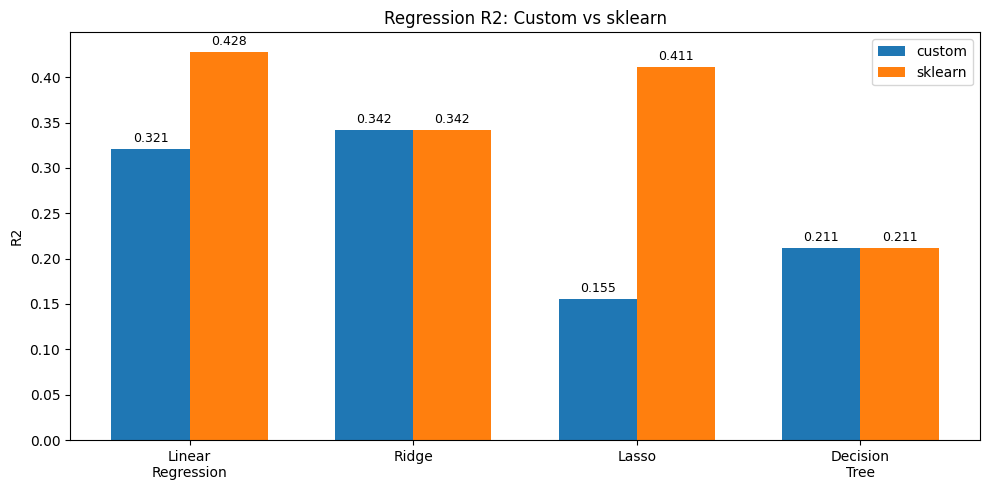

In [6]:

pairs = [
    ("MyLinearRegression (GD)", "sklearn LinearRegression"),
    ("MyRidge (analytical)", "sklearn Ridge"),
    ("MyLasso (GD)", "sklearn Lasso"),
    ("MyDesisionTreeRegressor", "sklearn DecisionTreeRegressor"),
]
labels = ["Linear\nRegression", "Ridge", "Lasso", "Decision\nTree"]
df_reg = pd.DataFrame(reg_results)
my_vals = [df_reg.loc[df_reg["Model"] == a, "R2"].values[0] for a, _ in pairs]
sk_vals = [df_reg.loc[df_reg["Model"] == b, "R2"].values[0] for _, b in pairs]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_my = ax.bar(x - width/2, my_vals, width, label="custom")
bars_sk = ax.bar(x + width/2, sk_vals, width, label="sklearn")

ax.bar_label(bars_my, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars_sk, fmt="%.3f", padding=3, fontsize=9)

ax.set_ylabel("R2")
ax.set_title("Regression R2: Custom vs sklearn")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

# Сравнение алгоритмов классификации

<h3> для алгоритмов классификации был использован датасет в котором по 30 числовым признакам

необходимо предсказать является ли опухоль доброкачественной или нет

## Загрузка и разделение датасета на тренировочную и тестовую выборки

In [7]:
bc = load_breast_cancer()
Xc = bc.data
yc = bc.target

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

scaler_c = StandardScaler()
Xc_train_sc = scaler_c.fit_transform(Xc_train)
Xc_test_sc  = scaler_c.transform(Xc_test)

Xc_train_df = pd.DataFrame(Xc_train_sc)
Xc_test_df  = pd.DataFrame(Xc_test_sc)
yc_train_s  = pd.Series(yc_train)
yc_test_s   = pd.Series(yc_test)

## обучение всех регрессоров

In [8]:
clf_results = []

def clf_row(name, y_true, y_pred):
    clf_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Recall": recall_score(y_true, y_pred)
    })

# Logistic Regression
my_logreg = MyLogisticRegressionSGD(epochs=100, learning_rate=0.01)
my_logreg.fit(Xc_train_sc, yc_train)
clf_row("MyLogisticRegressionSGD", yc_test, my_logreg.predict(Xc_test_sc))

sk_logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn LogisticRegression", yc_test, sk_logreg.predict(Xc_test_sc))

# knn
my_knn = MyKNN(n_neighbors=5)
my_knn.fit(Xc_train_sc, yc_train)
clf_row("MyKNN (k=5)", yc_test, my_knn.predict(Xc_test_sc))

sk_knn = KNeighborsClassifier(n_neighbors=5).fit(Xc_train_sc, yc_train)
clf_row("sklearn KNeighborsClassifier", yc_test, sk_knn.predict(Xc_test_sc))

# Naive Bayes
my_nb = NB()
my_nb.fit(Xc_train_df, yc_train_s)
clf_row("NB (Gaussian)", yc_test, my_nb.predict(Xc_test_df))

sk_nb = GaussianNB().fit(Xc_train_sc, yc_train)
clf_row("sklearn GaussianNB", yc_test, sk_nb.predict(Xc_test_sc))

# Decision Tree Classifier
my_dtc = MyDesisionTreeClassifier(max_depth=4)
my_dtc.fit(Xc_train_sc, yc_train)
clf_row("MyDesisionTreeClassifier", yc_test, my_dtc.predict(Xc_test_sc))

sk_dtc = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn DecisionTreeClassifier", yc_test, sk_dtc.predict(Xc_test_sc))

# Random Forest
my_rf = MyRandomForestClassifier(n_estimators=50, max_depth=5, random_state=RANDOM_STATE)
my_rf.fit(Xc_train_sc, yc_train)
clf_row("MyRandomForestClassifier", yc_test, my_rf.predict(Xc_test_sc))

sk_rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn RandomForestClassifier", yc_test, sk_rf.predict(Xc_test_sc))

# Gradient Boosting
my_gbdt = MyGBDTClassifier(n_estimators=50, max_depth=3, learning_rate=0.1)
my_gbdt.fit(Xc_train_sc, yc_train)
clf_row("MyGBDTClassifier", yc_test, my_gbdt.predict(Xc_test_sc))

sk_gbdt = GradientBoostingClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn GradientBoostingClassifier", yc_test, sk_gbdt.predict(Xc_test_sc))

# Extra Trees
my_et = ExtraTreesClassifier(n_estimators=50, max_depth=5)
my_et.fit(Xc_train_sc, yc_train)
clf_row("ExtraTreesClassifier", yc_test, my_et.predict(Xc_test_sc))

sk_et = SkExtraTreesClassifier(n_estimators=50, max_depth=5, random_state=RANDOM_STATE).fit(Xc_train_sc, yc_train)
clf_row("sklearn ExtraTreesClassifier", yc_test, sk_et.predict(Xc_test_sc))

pd.DataFrame(clf_results)

c:\Users\qa1ro\OneDrive\Рабочий стол\projects\ml-algs-implementation\src\supervised\naive_bayes\naive_bayes.py:32: RuntimeWarning: divide by zero encountered in log
  log_p1 = np.log(self.P_1) + np.sum(np.log(self._calc(X, self.E_1, std1)), axis=1)


,Model,Accuracy,Recall
0,MyLogisticRegressionSGD,0.9912,1.000000
1,sklearn LogisticRegression,0.9912,1.000000
2,MyKNN (k=5),0.9825,1.000000
3,sklearn KNeighborsClassifier,0.9825,1.000000
4,NB (Gaussian),0.9298,0.930556
5,sklearn GaussianNB,0.9298,0.930556
6,MyDesisionTreeClassifier,0.9211,0.930556
7,sklearn DecisionTreeClassifier,0.9123,0.944444
8,MyRandomForestClassifier,0.9386,0.958333
9,sklearn RandomForestClassifier,0.9474,0.972222


## визуализация

In [9]:
pairs_clf = [
    ("MyLogisticRegressionSGD", "sklearn LogisticRegression"),
    ("MyKNN (k=5)", "sklearn KNeighborsClassifier"),
    ("NB (Gaussian)", "sklearn GaussianNB"),
    ("MyDesisionTreeClassifier", "sklearn DecisionTreeClassifier"),
    ("MyRandomForestClassifier", "sklearn RandomForestClassifier"),
    ("MyGBDTClassifier", "sklearn GradientBoostingClassifier"),
    ("ExtraTreesClassifier", "sklearn ExtraTreesClassifier"),
]
labels_clf = ["Logistic\nRegression", "KNN", "Naive\nBayes", "Decision\nTree", "Random\nForest", "GBDT", "Extra\nTrees"]
df_clf  = pd.DataFrame(clf_results)
my_vals_clf = [df_clf.loc[df_clf["Model"] == a, "Recall"].values[0] for a, _ in pairs_clf]
sk_vals_clf = [df_clf.loc[df_clf["Model"] == b, "Recall"].values[0] for _, b in pairs_clf]

x = np.arange(len(labels_clf))
width = 0.35

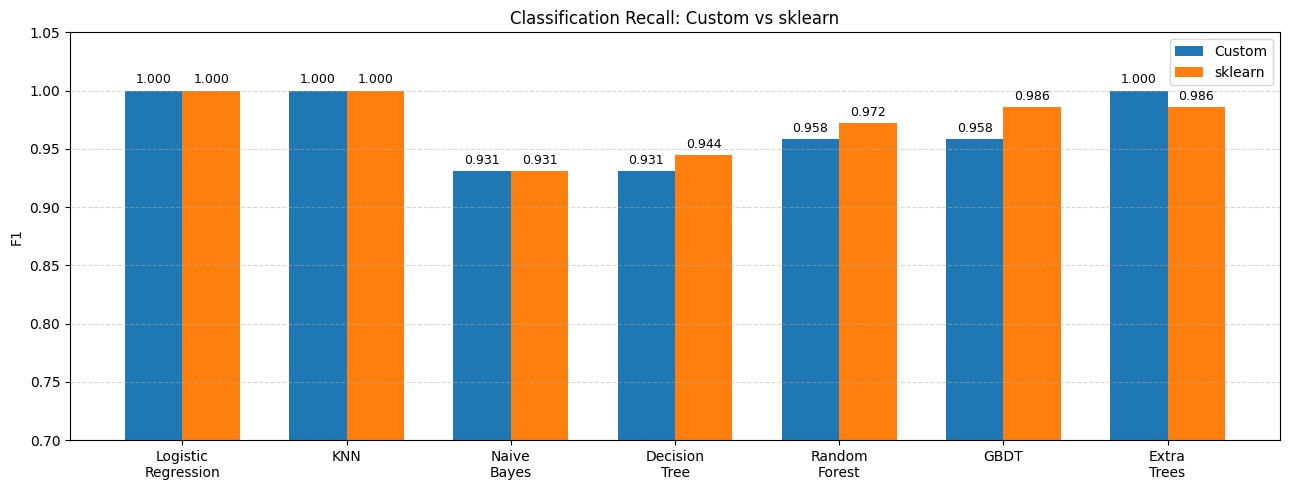

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
bars_my = ax.bar(x - width/2, my_vals_clf, width, label="Custom")
bars_sk = ax.bar(x + width/2, sk_vals_clf, width, label="sklearn")

ax.bar_label(bars_my, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars_sk, fmt="%.3f", padding=3, fontsize=9)

ax.set_ylabel("F1")
ax.set_title("Classification Recall: Custom vs sklearn")
ax.set_xticks(x)
ax.set_xticklabels(labels_clf)
ax.set_ylim(0.7, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Проверка алгоритмов обучения без учителя

### Для тестирования алгоритмов кластеризации был использован синтетический датасет make_blobs — 500 точек, 3 кластера в 2D пространстве с умеренным разбросом

## Генерация и масштабирование датасета

In [11]:
X_cl, y_cl_true = make_blobs(n_samples=500, centers=3, cluster_std=0.9, random_state=RANDOM_STATE, return_centers=False)
X_cl_sc = scaler_c.fit_transform(X_cl)

## Обучение всех алгоритмов кластеризации

In [12]:
clust_results = []

def clust_row(name, X, labels):
    mask = (labels != -1)
    n_found = len(set(labels[mask]))
    n_noise = int(np.sum(labels == -1))
    if n_found > 1 and mask.sum() > n_found:
        sil = round(silhouette_score(X[mask], labels[mask]), 4)
    else:
        sil = np.nan
    clust_results.append({
        "Model": name,
        "Clusters found": n_found,
        "Noise points": n_noise,
        "Silhouette": sil,
    })

# KMeans
my_km = MyKMeans(n_clusters=3, random_state=RANDOM_STATE)
my_km.fit(X_cl_sc)
clust_row("MyKMeans (k=3)", X_cl_sc, my_km.labels_)

sk_km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
sk_km.fit(X_cl_sc)
clust_row("sklearn KMeans (k=3)", X_cl_sc, sk_km.labels_)

# DBSCAN
my_db = MyDBScan(eps=0.3, min_samples=5)
my_db.fit(X_cl_sc)
clust_row("MyDBScan (eps=0.3)", X_cl_sc, my_db.labels_)

sk_db = DBSCAN(eps=0.3, min_samples=5)
sk_db.fit(X_cl_sc)
clust_row("sklearn DBSCAN (eps=0.3)", X_cl_sc, sk_db.labels_)

# GMM
np.random.seed(RANDOM_STATE)
my_gmm = MyGMM(n_components=3, max_iter=100)
my_gmm.fit(X_cl_sc)
clust_row("MyGMM (k=3)", X_cl_sc, my_gmm.labels_)

sk_gmm = GaussianMixture(n_components=3, max_iter=100, random_state=RANDOM_STATE)
sk_gmm.fit(X_cl_sc)
clust_row("sklearn GaussianMixture (k=3)", X_cl_sc, sk_gmm.predict(X_cl_sc))

pd.DataFrame(clust_results)

,Model,Clusters found,Noise points,Silhouette
0,MyKMeans (k=3),3,0,0.7502
1,sklearn KMeans (k=3),3,0,0.7502
2,MyDBScan (eps=0.3),3,4,0.7539
3,sklearn DBSCAN (eps=0.3),3,4,0.7539
4,MyGMM (k=3),3,0,0.7502
5,sklearn GaussianMixture (k=3),3,0,0.7502


## Визуализация

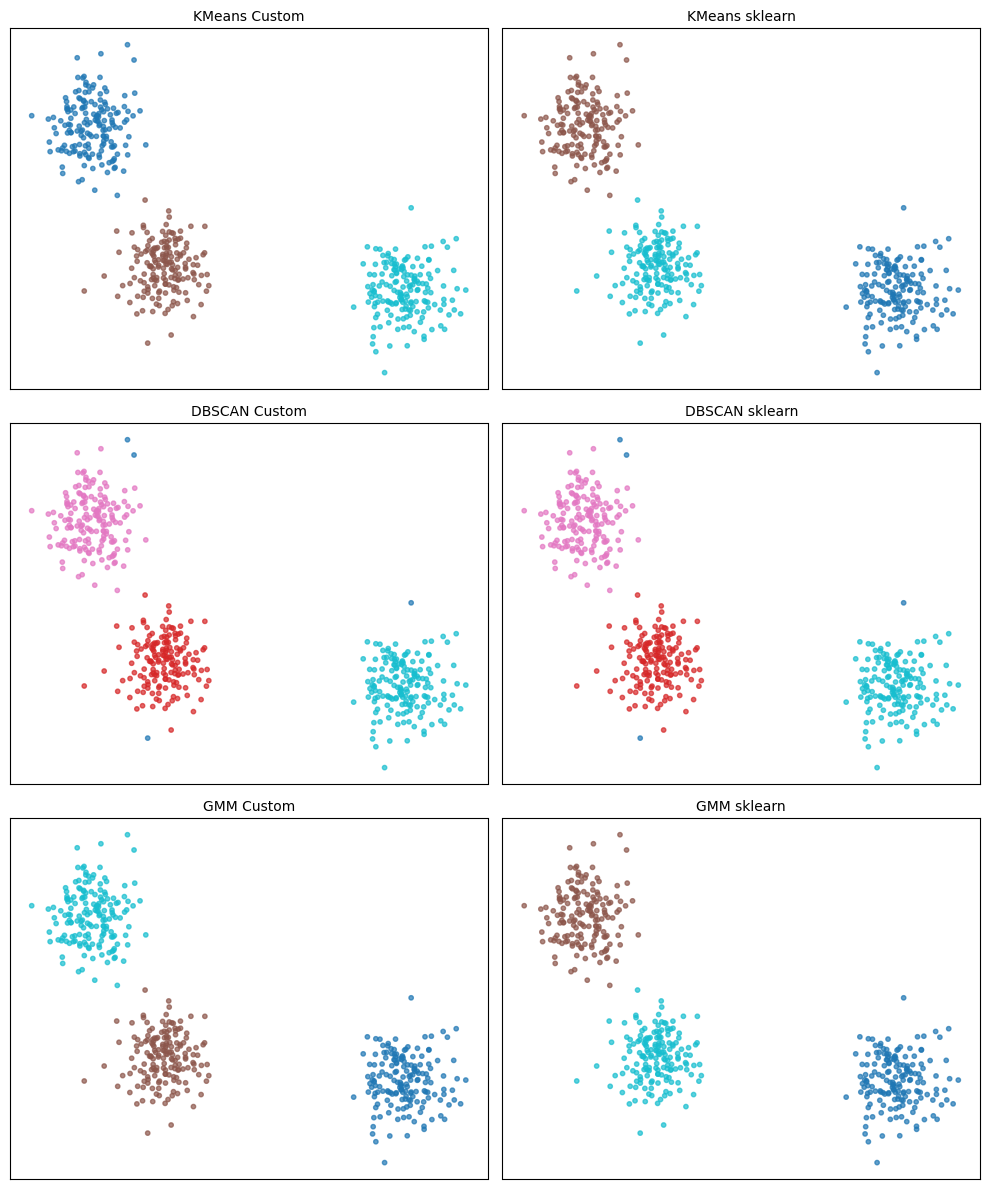

In [13]:
algo_names = ["KMeans", "DBSCAN", "GMM"]
scatter_data = [(my_km.labels_, sk_km.labels_), (my_db.labels_, sk_db.labels_), (my_gmm.labels_, sk_gmm.predict(X_cl_sc))]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for row, (my_lbls, sk_lbls) in enumerate(scatter_data):
    for col, (lbls, side) in enumerate([(my_lbls, "Custom"), (sk_lbls, "sklearn")]):
        ax = axes[row, col]
        ax.scatter(X_cl_sc[:, 0], X_cl_sc[:, 1], c=lbls, cmap="tab10", s=10, alpha=0.7)
        ax.set_title(f"{algo_names[row]} {side}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


# Сравнение методов валидации

In [14]:
df_val = pd.DataFrame({
    'x': range(12),
    'y': [0,0,0,0,0,0,1,1,1,1,1,1],
    'group': [0,0,0,1,1,1,2,2,2,3,3,3],
})

def print_fold(fold, my_tr, my_te, sk_tr, sk_te):
    print(f"\nFold {fold}")
    print(f"My train = {my_tr.tolist()} test={my_te.tolist()}")
    print(f"SK train = {sk_tr.tolist()} test={sk_te.tolist()}")
    print(df_val.iloc[my_te].to_string())

print(df_val.to_string())

     x  y  group
0    0  0      0
1    1  0      0
2    2  0      0
3    3  0      1
4    4  0      1
5    5  0      1
6    6  1      2
7    7  1      2
8    8  1      2
9    9  1      3
10  10  1      3
11  11  1      3


In [15]:
my_splits = list(MyKFold(n_splits=3).split(df_val))
sk_splits = list(KFold(n_splits=3).split(df_val))

print("KFold (n_splits=3)")
for fold in range(len(my_splits)):
    my_tr, my_te = my_splits[fold]
    sk_tr, sk_te = sk_splits[fold]
    print_fold(fold, my_tr, my_te, sk_tr, sk_te)

KFold (n_splits=3)

Fold 0
My train = [4, 5, 6, 7, 8, 9, 10, 11] test=[0, 1, 2, 3]
SK train = [4, 5, 6, 7, 8, 9, 10, 11] test=[0, 1, 2, 3]
   x  y  group
0  0  0      0
1  1  0      0
2  2  0      0
3  3  0      1

Fold 1
My train = [0, 1, 2, 3, 8, 9, 10, 11] test=[4, 5, 6, 7]
SK train = [0, 1, 2, 3, 8, 9, 10, 11] test=[4, 5, 6, 7]
   x  y  group
4  4  0      1
5  5  0      1
6  6  1      2
7  7  1      2

Fold 2
My train = [0, 1, 2, 3, 4, 5, 6, 7] test=[8, 9, 10, 11]
SK train = [0, 1, 2, 3, 4, 5, 6, 7] test=[8, 9, 10, 11]
     x  y  group
8    8  1      2
9    9  1      3
10  10  1      3
11  11  1      3


In [16]:
my_splits = list(MyStratifiedKFold(n_splits=3).split(df_val, df_val['y']))
sk_splits = list(StratifiedKFold(n_splits=3).split(df_val, df_val['y']))

print("StratifiedKFold (n_splits=3)")
for fold in range(len(my_splits)):
    my_tr, my_te = my_splits[fold]
    sk_tr, sk_te = sk_splits[fold]
    print_fold(fold, my_tr, my_te, sk_tr, sk_te)

StratifiedKFold (n_splits=3)

Fold 0
My train = [2, 3, 4, 5, 8, 9, 10, 11] test=[0, 1, 6, 7]
SK train = [2, 3, 4, 5, 8, 9, 10, 11] test=[0, 1, 6, 7]
   x  y  group
0  0  0      0
1  1  0      0
6  6  1      2
7  7  1      2

Fold 1
My train = [0, 1, 4, 5, 6, 7, 10, 11] test=[2, 3, 8, 9]
SK train = [0, 1, 4, 5, 6, 7, 10, 11] test=[2, 3, 8, 9]
   x  y  group
2  2  0      0
3  3  0      1
8  8  1      2
9  9  1      3

Fold 2
My train = [0, 1, 2, 3, 6, 7, 8, 9] test=[4, 5, 10, 11]
SK train = [0, 1, 2, 3, 6, 7, 8, 9] test=[4, 5, 10, 11]
     x  y  group
4    4  0      1
5    5  0      1
10  10  1      3
11  11  1      3


In [17]:
my_splits = list(MyGroupKFold(n_splits=3).split(df_val, groups=df_val['group']))
sk_splits = list(GroupKFold(n_splits=3).split(df_val, groups=df_val['group']))

print("GroupKFold (n_splits=3)  groups=[0,0,0,1,1,1,2,2,2,3,3,3]")
for fold in range(len(my_splits)):
    my_tr, my_te = my_splits[fold]
    sk_tr, sk_te = sk_splits[fold]
    print_fold(fold, my_tr, my_te, sk_tr, sk_te)

GroupKFold (n_splits=3)  groups=[0,0,0,1,1,1,2,2,2,3,3,3]

Fold 0
My train = [6, 7, 8, 9, 10, 11] test=[0, 1, 2, 3, 4, 5]
SK train = [3, 4, 5, 6, 7, 8] test=[0, 1, 2, 9, 10, 11]
   x  y  group
0  0  0      0
1  1  0      0
2  2  0      0
3  3  0      1
4  4  0      1
5  5  0      1

Fold 1
My train = [0, 1, 2, 3, 4, 5, 9, 10, 11] test=[6, 7, 8]
SK train = [0, 1, 2, 3, 4, 5, 9, 10, 11] test=[6, 7, 8]
   x  y  group
6  6  1      2
7  7  1      2
8  8  1      2

Fold 2
My train = [0, 1, 2, 3, 4, 5, 6, 7, 8] test=[9, 10, 11]
SK train = [0, 1, 2, 6, 7, 8, 9, 10, 11] test=[3, 4, 5]
     x  y  group
9    9  1      3
10  10  1      3
11  11  1      3


In [18]:
my_splits = list(MyTimeSeriesSplit(n_splits=3).split(df_val))
sk_splits = list(TimeSeriesSplit(n_splits=3).split(df_val))

print("TimeSeriesSplit (n_splits=3)")
for fold in range(len(my_splits)):
    my_tr, my_te = my_splits[fold]
    sk_tr, sk_te = sk_splits[fold]
    print_fold(fold, my_tr, my_te, sk_tr, sk_te)

TimeSeriesSplit (n_splits=3)

Fold 0
My train = [0, 1, 2] test=[3, 4, 5]
SK train = [0, 1, 2] test=[3, 4, 5]
   x  y  group
3  3  0      1
4  4  0      1
5  5  0      1

Fold 1
My train = [0, 1, 2, 3, 4, 5] test=[6, 7, 8]
SK train = [0, 1, 2, 3, 4, 5] test=[6, 7, 8]
   x  y  group
6  6  1      2
7  7  1      2
8  8  1      2

Fold 2
My train = [0, 1, 2, 3, 4, 5, 6, 7, 8] test=[9, 10, 11]
SK train = [0, 1, 2, 3, 4, 5, 6, 7, 8] test=[9, 10, 11]
     x  y  group
9    9  1      3
10  10  1      3
11  11  1      3


# Сравнение нейронных сетей

## MLP vs sklearn MLPClassifier - breast cancer


In [ ]:
np.random.seed(RANDOM_STATE)
my_mlp = My_MLP(n_hidden=128, activation='relu', lr=0.01, epochs=100, batch_size=32)
my_mlp.fit(Xc_train_sc, yc_train)

sk_mlp = MLPClassifier(
    hidden_layer_sizes=(128,), activation='relu',
    learning_rate_init=0.01, max_iter=100, batch_size=32,
    random_state=RANDOM_STATE,
)
sk_mlp.fit(Xc_train_sc, yc_train)

my_pred = my_mlp.predict(Xc_test_sc)
sk_pred = sk_mlp.predict(Xc_test_sc)

pd.DataFrame([
    {"Model": "My_MLP", "Accuracy": round(accuracy_score(yc_test, my_pred), 4), "F1": round(f1_score(yc_test, my_pred), 4)},
    {"Model": "sklearn MLP", "Accuracy": round(accuracy_score(yc_test, sk_pred), 4), "F1": round(f1_score(yc_test, sk_pred), 4)}
])

,Model,Accuracy,F1
0,My_MLP,0.9825,0.9861
1,sklearn MLPClassifier,0.9912,0.9931
